In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/CSMODEL_MCO/Raw_Dataset/uncompressed')

['IHME_GLOBAL_OBESITY_ADOLESCENT_1990_2050_AGES_5_24_OW_OB_Y2025M02D06.CSV',
 'IHME_GLOBAL_OBESITY_ADOLESCENT_1990_2050_AGES_5_24_OW_ONLY_Y2025M02D06.CSV',
 'OB_ONLY.CSV',
 'OB_ONLY.CSV.gsheet']

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/CSMODEL_MCO/Raw_Dataset/uncompressed/OB_ONLY.CSV')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Abstract

# Dataset Description

The dataset used in this project is obtained from the Global Burden of Disease Study 2021 (GBD, 2021), conducted by the Health Institute for Health Metrics and Evaluations (IMHE). It contains estimates of annual prevelance of overweight and obesity among children and adolescents across multiple countries and territories.

The data covers the period throughout 1990-2021, with projections from 2022 to 2050. Though the data includes overweight and obesity, the analysis will solely focus on obesity data. The dataset is based on modeled estimates rather than direct measurements from every year and country, so results reflect approximations of obesity prevalence. Forecasted values from 2022-2050 are subject to uncertainty and should be interpreted as projections based on current trends and assumptions.



In [ ]:

print(df.info())
print()
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170556 entries, 0 to 170555
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   metric          170556 non-null  object 
 1   location_level  170556 non-null  object 
 2   location_name   170556 non-null  object 
 3   location_id     170556 non-null  int64  
 4   Sex             170556 non-null  object 
 5   sex_id          170556 non-null  int64  
 6   age_group_name  170556 non-null  object 
 7   age_group_id    170556 non-null  int64  
 8   year_id         170556 non-null  int64  
 9   mean_prev       170556 non-null  float64
 10  lower_prev      170556 non-null  float64
 11  upper_prev      170556 non-null  float64
 12  mean_change     170556 non-null  float64
 13  lower_change    170556 non-null  float64
 14  upper_change    170556 non-null  float64
dtypes: float64(6), int64(4), object(5)
memory usage: 19.5+ MB
None

Index(['metric', 'location_level', 'lo

**Structure of Data**

The dataset contains 15 variables, described as follows:

*   metric - The type of metric used for the estimate
*   location_level - Geographic level of the estimate (e.g., country or region)


*   location_name - Name of the location
*   location_id - A unique numeric identifier for each location


*   Sex - Gender category of the estimate
*   sex_id - A unique numeric identifier for sex category

*   age_group_name - The age group of the population
*   age_group_id - A unique numeric identifier for age group

*   year_id - Year of the estimate
*   mean prev - Estimated mean prevalence of obesity

* lower_prev - Lower bound (2.5%) of the prevalence estimate
* upper_prev - Upper bound (97.5%) of the prevalence estimate

* mean_change - Estimated mean percentage change in prevalence over time

* lower_change - Lower bound of the percentage change estimate

* upper_change - Upper bound of the percentage change estimate

#Data Cleaning and Preprocessing


**Removing the Projections of the dataset "2022-2050"**

In [ ]:
df = df[df['year_id']  <= 2021]
df['year_id'].max()

2021

**Check for missing values in the dataset.**

In [ ]:
df.isnull().sum()

,0
metric,0
location_level,0
location_name,0
location_id,0
Sex,0
sex_id,0
age_group_name,0
age_group_id,0
year_id,0
mean_prev,0


No missing values were found in the dataset, therefore no imputation or removal of records.

**Check for are duplicate rows in the dataset**

In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


Since there is no duplicate data, nothing will be removed.

**Then check for multiple representation of the same categorical value.**

In [ ]:
print(df['Sex'].unique())
print(df['location_level'].unique())
print(df['age_group_name'].unique())

['Male' 'Female' 'Both']
['Global' 'Super-Region' 'Region' 'Country']
['5 to 9' '10 to 14' '15 to 19' '20 to 24']


No multiple representation.

Check if there are outliers

This code finds and removes outliers by using the Interquartile Range (IQR) method, which looks at the middle 50% of the data to see what a normal value looks like. It sets up top and bottom boundaries by going 1.5 times past this middle chunk. Anything that falls outside of those boundaries is considered an outlier and are erased from the dataset.

In [ ]:
numerical_cols = ['mean_prev', 'mean_change']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    has_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).any()

    if has_outliers:
          print(f"Yes, '{col}' has outliers.")
    else:
          print(f"No, '{col}' has no outliers.")


    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print("Outliers removed. New dataframe shape:", df.shape)

Yes, 'mean_prev' has outliers.
Outliers removed. New dataframe shape: (74235, 16)
Yes, 'mean_change' has outliers.
Outliers removed. New dataframe shape: (74139, 16)


# Research Question & Exploratory Data Analysis

## **Exploratory Data Analysis Questions**

**How has obesity prevalence changed over time among individuals aged 5-24?**

We will use Pearson Correlation to test whether there is a relationship between year and mean prevalence of obesity.

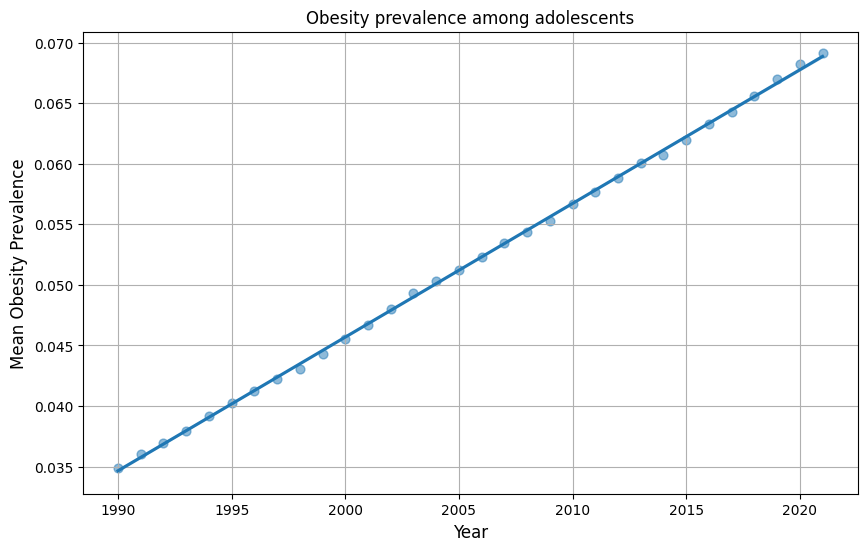

Pearsons Correlation: 0.9998


In [ ]:
df_filtered = df[(df['location_level'] == 'Country')] # filter country
get_mean=df_filtered.groupby('year_id')['mean_prev'].mean().reset_index() # get the mean of mean_prev per year
pearson=get_mean['year_id'].corr(get_mean['mean_prev'], method='pearson')

plt.figure(figsize=(10,6))
sns.regplot(
    data=get_mean,
    x='year_id',
    y='mean_prev',
    scatter_kws={'s':40, 'alpha':0.5}
)
plt.title("Obesity prevalence among adolescents")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mean Obesity Prevalence", fontsize=12)
plt.grid(True)
plt.show()
print(f'Pearsons Correlation: {pearson:.4f}')

With a value of 0.9994, this suggests a strong positive correlation between year and obesity prevalence, indicating that as the years progress, obesity rates also increase. However, this does not imply that the progression of years causes increased obesity prevalence. There are other factors that we need to consider such as lifestyle, nutrition, and socioeconomic status.


**What patterns of obesity prevalence can be observed across different age groups and sex?**

We will use bar graph to present the relationship between age, sex, and obesity rate.

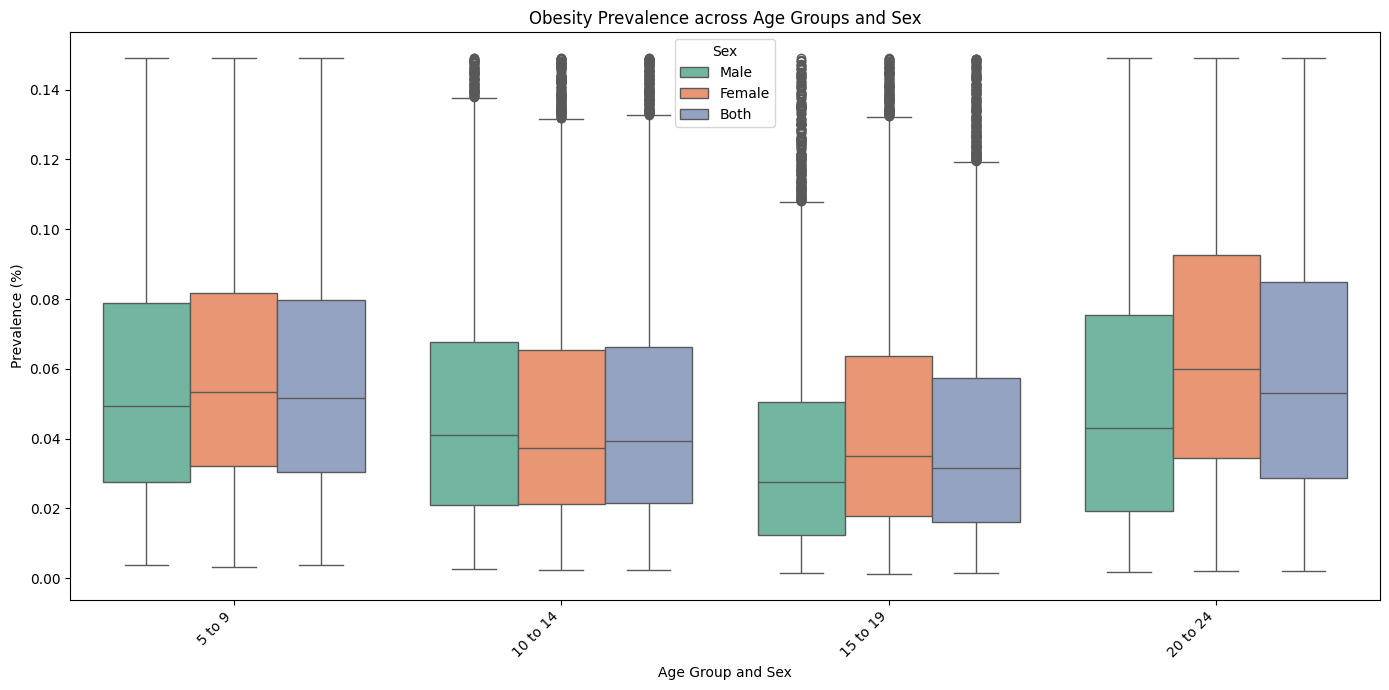

In [ ]:
# df['mean_prev_pct']=df['mean_prev']*100
# #group by age group and sex to automatically combine all years and locations
# aggregate_data=(df.groupby(['age_group_name','Sex'])['mean_prev_pct'].mean().reset_index())
# plot_data=aggregate_data.pivot(index='age_group_name',columns=['Sex'],values='mean_prev_pct')
# #arrange by gender
# plot_data=plot_data[['Female','Male','Both']]
# #create the bar plot
# plot_data.plot(
#     kind="bar",
#     edgecolor="w",
#     figsize=(12,6),
#     color=["#ff7f0e","#1f77b4","#7f7f7f"],
#     )
# #create label
# plt.xlabel('Age Group and Sex')
# plt.ylabel('Prevalence (%)')
# plt.title('Obesity Prevalence across Age Groups and Sex')
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()
# #calculate the mean, median, and standard deviation
# stats=(df.groupby(['age_group_name','Sex'])['mean_prev'].agg(Mean='mean',Median='median',Std='std').reset_index())
# print(stats)

plt.figure(figsize=(14,7))

sns.boxplot(
    data = df,
    x = 'age_group_name',
    y = 'mean_prev',
    hue = 'Sex',
    palette =  'Set2'
)

plt.xlabel('Age Group and Sex')
plt.ylabel('Prevalence (%)')
plt.title('Obesity Prevalence across Age Groups and Sex')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


Among all genders, the lowest obesity rate is observed in adolescents aged 15 to 19, while the highest is observed in those aged 20 to 24 with the rates very close to those in children aged 5 to 9. Within each age group analyzed, males had a higher obesity in the ages 10 to 14, otherwise the females had a significantly higher average obesity rate than males.

How does obesity prevalence vary across different geographic locations?

We will use bar graph to compare the mean obesity prevalence across different countries.

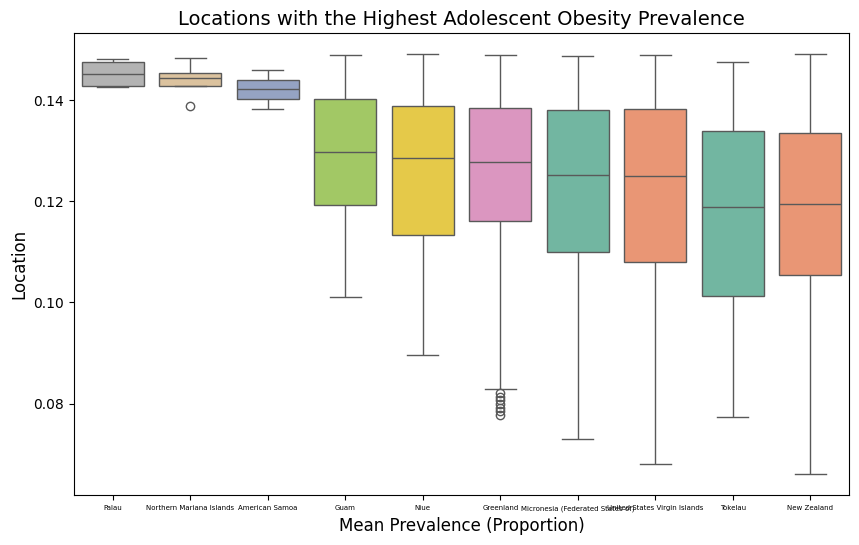

                        location_name      Mean    Median       Std
133                             Palau  0.145194  0.145032  0.002666
129          Northern Mariana Islands  0.143921  0.144275  0.003915
3                      American Samoa  0.142080  0.142093  0.003861
71                               Guam  0.128990  0.129695  0.013106
127                              Niue  0.125792  0.128610  0.016409
..                                ...       ...       ...       ...
103                        Madagascar  0.010456  0.007482  0.008104
95   Lao People's Democratic Republic  0.010051  0.008975  0.005828
30                           Cambodia  0.008125  0.006290  0.005323
28                            Burundi  0.008011  0.006874  0.004964
194                          Viet Nam  0.005918  0.005269  0.002868

[198 rows x 4 columns]


In [ ]:
# top_10=(df_filtered.groupby('location_name')['mean_prev'].mean().reset_index().sort_values(by='mean_prev', ascending=False).head(10))
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_10,
#     x='location_name',
#     y='mean_prev'
# )
# plt.title("Locations with the Highest Adolescent Obesity Prevalence", fontsize=14)
# plt.xlabel("Mean Prevalence (Proportion)", fontsize=12)
# plt.ylabel("Location", fontsize=12)
# plt.xticks(fontsize=5)
# plt.show()
# country_stats=(df_filtered.groupby('location_name')['mean_prev'].agg(Mean='mean',Median='median',Std='std').reset_index().sort_values(by='Mean', ascending=False))

# print(country_stats)

top_10 = (
    df[df['location_level'].str.lower() == 'country']
    .groupby('location_name')['mean_prev']
    .mean()
    .nlargest(10)
    .index
)

df_top_countries = df[df['location_name'].isin(top_10)]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top_countries,
    x='location_name',
    y='mean_prev',
    hue = 'location_name',
    palette = 'Set2',
    order=top_10
)

plt.title("Locations with the Highest Adolescent Obesity Prevalence", fontsize=14)
plt.xlabel("Mean Prevalence (Proportion)", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.xticks(fontsize=5)
plt.show()
country_stats=(df_filtered.groupby('location_name')['mean_prev'].agg(Mean='mean',Median='median',Std='std').reset_index().sort_values(by='Mean', ascending=False))

print(country_stats)

Obesity prevalence varies significantly across different geographic locations. The graph shows that Cook Islands leads the ranking in obesity prevalence, followed closely by Pacific Island Nations such as Nauru, Niue, and Tonga.

### How do demographic and geographic factors influence obesity prevalence among individuals aged 5–24 from the year 1990-2050?


The first EDA connects to the research since this EDA is used to analyze and track the overall trend of obesity rates in people aged 5-24, which will help to analyze whether obesity rates are continuing to rise or fall, or stabilizing.

The second EDA question analyzes the relationship between age, sex, and obesity rate, which will help analyze whether demographic factors influence obesity rates. By breaking down the data into more specific age groups and sexes, the problem can identify which specific subgroups are bearing the heaviest burden or experiencing the fastest growth.



The third EDA question analyzes whether regional factors influence obesity rates. Obesity is significantly influenced by local drivers such as regional diet, national healthcare policies, socioeconomic development, and urbanization. Through data analysis, we can identify high-risk areas and provide necessary background information for analyzing whether population trends are similar globally or whether there are significant differences across different regions.


# Data Mining

# Statistical Inference

# Summary, Conclusions, and Recommendations

# References & Disclosures